In [1]:
#engine imports
import glob
import ntpath
import pandas as pd
data = []

In [2]:


a=1
b=2
c=3


data.append([a, b, c])

df = pd.DataFrame(data, columns=['A', 'B', 'C'])

In [3]:
df

,A,B,C
0,1,2,3


In [4]:
data=[]

In [5]:
#lime imports
import os
import keras
from keras.applications import xception as inc_net
from keras.preprocessing import image
from keras.models import load_model
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
print('Notebook run using keras:', keras.__version__)
import lime
import csv



Using TensorFlow backend.


Notebook run using keras: 2.2.4


In [6]:
import h5py

f = h5py.File('E:/expr1/Xception-with-Your-Own-Dataset/result_exp1/model_fine_final.h5','r+')

data_p = f.attrs['training_config']
data_p = data_p.decode().replace("learning_rate","lr").encode()
f.attrs['training_config'] = data_p
f.close()

inet_model = load_model('E:/expr1/Xception-with-Your-Own-Dataset/result_exp1/model_fine_final.h5')

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Use tf.cast instead.


In [7]:
def transform_img_fn(path_list):
    out = []
    for img_path in path_list:
        img = image.load_img(img_path, target_size=(299, 299))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = inc_net.preprocess_input(x)
        out.append(x)
    return np.vstack(out)

In [8]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
%load_ext autoreload
%autoreload 2
explainer = lime_image.LimeImageExplainer()

In [9]:
def converter(x):

    #x has shape (batch, width, height, channels)
    return (0.21 * x[:,:,:,:1]) + (0.72 * x[:,:,:,1:2]) + (0.07 * x[:,:,:,-1:])

def getmasks(filename):

    img_path = 'c:/Users/andradee/\Documents/audiodeep/image_downloader/image_downloader/images/german-shepherd 2020_09_11_total/teste/'+filename
    img = image.load_img(img_path, target_size=(299, 299))
    img_tensor = image.img_to_array(img)
    img_tensor = np.expand_dims(img_tensor, axis=0)
    img_tensor /= 255.

    plt.imshow(img_tensor[0])
    plt.show()

    print(img_tensor.shape)

    file_class='E:/expr1/Xception-with-Your-Own-Dataset/classes_exp1_german_add.txt'

    classes = []
    with open(file_class, 'r') as f:
        classes = list(map(lambda x: x.strip(), f.readlines()))



    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    x = inc_net.preprocess_input(x)


    images = np.vstack([x])
    pred = inet_model.predict(images, batch_size=10)

    num_class=pred.shape[1]

    result = [(classes[i], float(pred[0,i]) * 100.0) for i in range(num_class)]
    result.sort(reverse=True, key=lambda x: x[1])

    for i in range(num_class):
        (class_name, prob) = result[i]
        #print(i)
        #print("Top %d ====================" % (i + 1))
        #print("Class name: %s" % (class_name))
        #print("Probability: %.2f%%" % (prob))
        print('%s, %.2f%%' % (class_name, prob))

        
                
         
            

    #%%time
    # Hide color is the color for a superpixel turned OFF. Alternatively, if it is NONE, the superpixel will be replaced by the average of its pixels
    explanation = explainer.explain_instance(images[0], inet_model.predict, top_labels=5,hide_color=0, num_samples=1000)
  
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=10, hide_rest=True)
    plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
    plt.show()
    plt.imshow(mask)
    plt.show()
    
    mask2_path = 'c:/Users/andradee/\Documents/audiodeep/image_downloader/image_downloader/images/german-shepherd 2020_09_11_total/mask/'+filename
    mask2 = image.load_img(mask2_path, target_size=(299, 299))
    mask2_tensor = image.img_to_array(mask2)
    mask2_tensor = np.expand_dims(mask2_tensor, axis=0)
    mask2_tensor /= 255.

    plt.imshow(mask2_tensor[0])
    plt.show()
    
    mask2=converter(mask2_tensor)
    mask2 = mask2.reshape([ 299, 299])
    mask2=(mask2 < 1)
    mask=mask

    plt.imshow(mask)
    plt.show()
    
    maskf_fp=(1-mask2)*mask #falso positivo
    maskf_fn=mask2*(1-mask) #falso negativo
    maskf_tp=mask2*mask #verdadeiro positivo
    maskf_tn=(1-mask2)*(1-mask) #verdadeiro negativo
    
    print("True Positive")
    plt.imshow(maskf_tp)
    plt.show()
    
    print("True Negative")
    plt.imshow(maskf_tn)
    plt.show()
    
    print("False Positive")
    plt.imshow(maskf_fp)
    plt.show()
    
    print("False Negative")
    plt.imshow(maskf_fn)
    plt.show()
    
    fp= np.count_nonzero(maskf_fp == 1)/ (299*299) *100
    fn = np.count_nonzero(maskf_fn == 1)/ (299*299) *100
    tp =np.count_nonzero(maskf_tp == 1)/ (299*299) *100
    tn = np.count_nonzero(maskf_tn == 1)/ (299*299) *100
    acc=((tp+tn)/(fp+tp+fn+tn)*100)
    pre=(tp/(tp+fp))*100
    rec=(tp/(tp+fn))*100
    spe=(tn/(tn+fp)*100)
    f1=2*(pre*rec)/(pre+rec)
        
    print("TP - FP:",tp, fp)
    print("FN - TN:",fn, tn)
    print("Acurracy:", acc)
    print("Precision:",pre )
    print("Recall:", rec)
    print("Specificity:", spe)
    
    (class_name, prob) = result[0]
    data.append([filename, class_name, prob, fp, fn, tp, tn, acc, pre, rec, spe, f1])
    print(data)
    
    

1 11.german-shepherd-ap-aozjlq-645.png


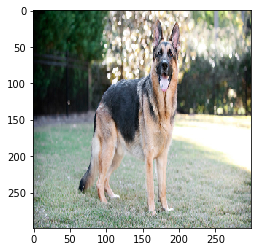

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


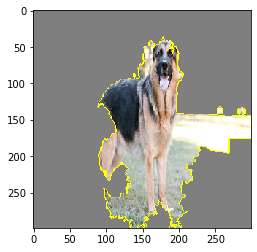

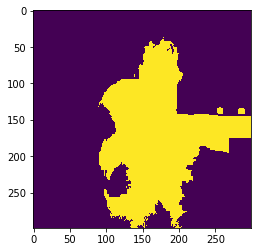

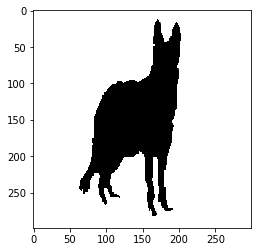

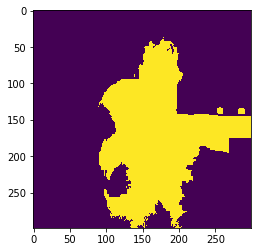

True Positive


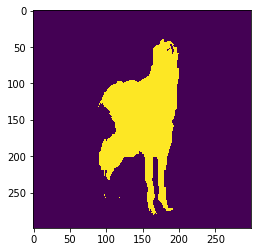

True Negative


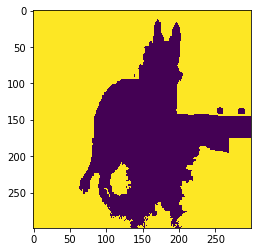

False Positive


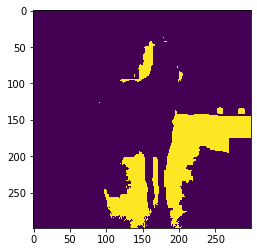

False Negative


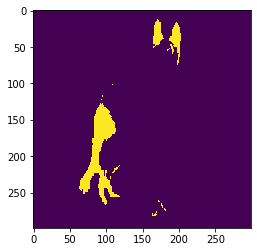

TP - FP: 14.855538528651804 13.677699354593347
FN - TN: 3.927249135915706 67.53951298083915
Acurracy: 82.39505150949095
Precision: 52.06397741973422
Recall: 79.09123392091472
Specificity: 83.15911250671405
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015]]
2 11.german-shepherd-dog.png


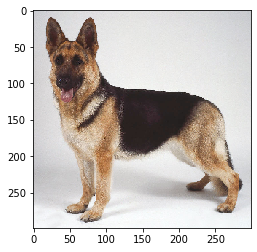

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


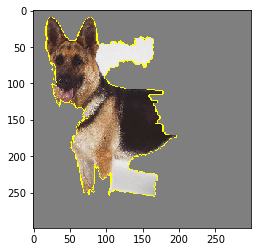

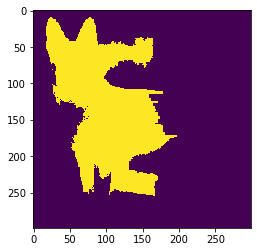

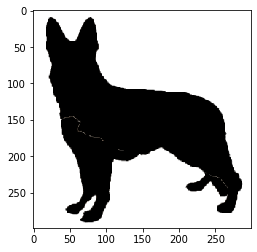

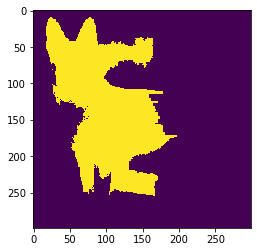

True Positive


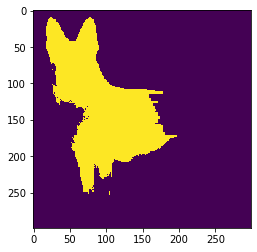

True Negative


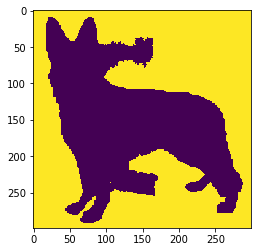

False Positive


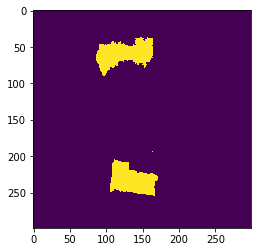

False Negative


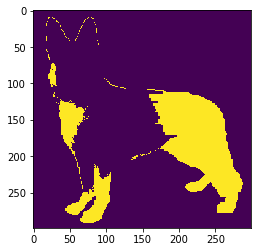

TP - FP: 20.47068824733504 4.979810069238599
FN - TN: 16.74925336405633 57.80024831937003
Acurracy: 78.27093656670507
Precision: 80.43334944842438
Recall: 54.9992486851991
Specificity: 92.06784734347718
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399]]
3 11.gsd_bred_to_do_header_.png


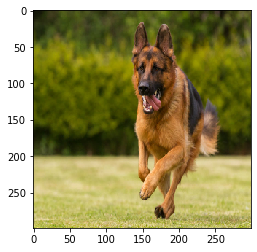

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


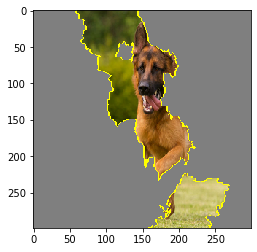

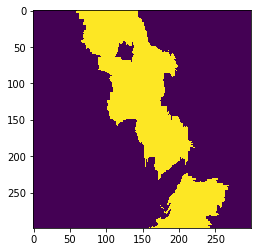

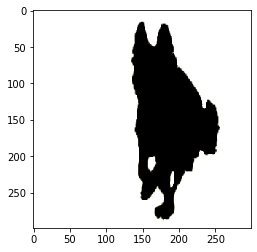

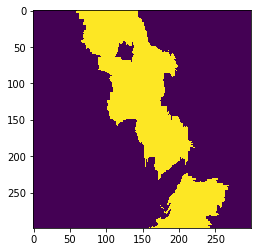

True Positive


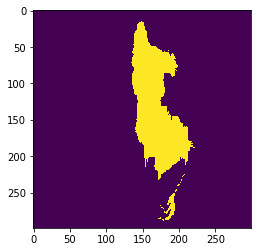

True Negative


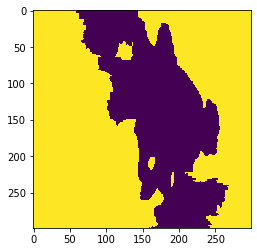

False Positive


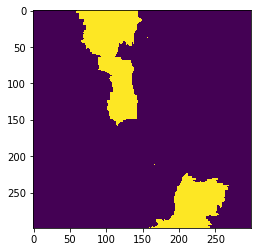

False Negative


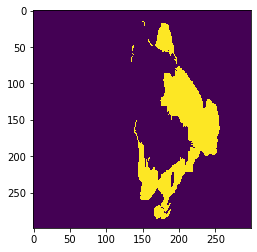

TP - FP: 10.678851466985828 13.013277256406527
FN - TN: 10.421583651189584 65.88628762541806
Acurracy: 76.5651390924039
Precision: 45.073414852934235
Recall: 50.6096268023749
Specificity: 83.50652848859464
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932]]
4 14.NGHT-Boxed640x480.png


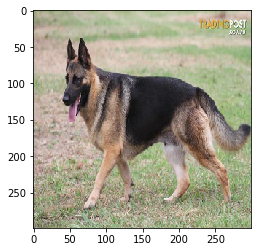

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


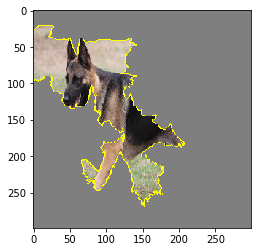

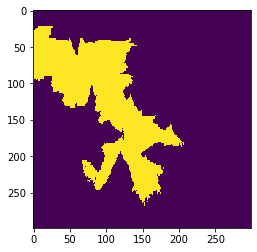

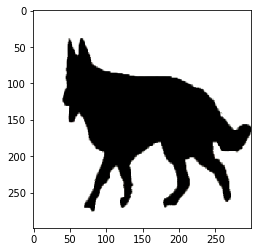

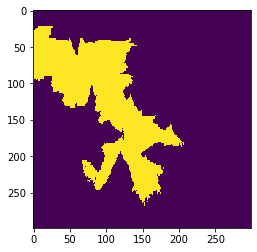

True Positive


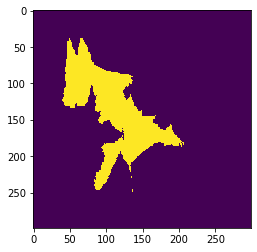

True Negative


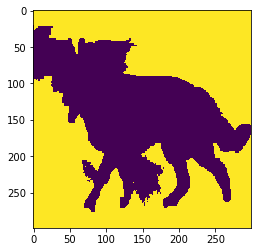

False Positive


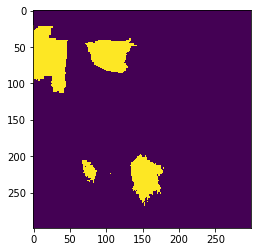

False Negative


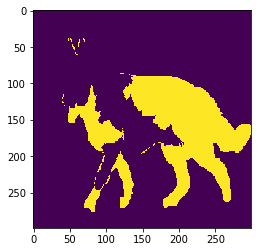

TP - FP: 12.092705898144317 8.43167302379168
FN - TN: 19.857719712307468 59.61790136575653
Acurracy: 71.71060726390084
Precision: 58.918742165785595
Recall: 37.848340568547826
Specificity: 87.60951394710456
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0,

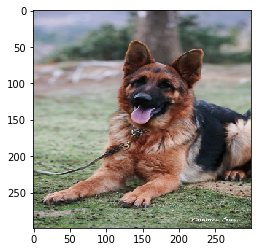

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


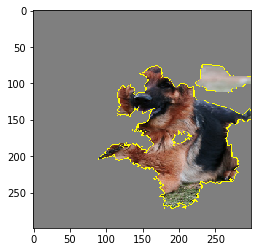

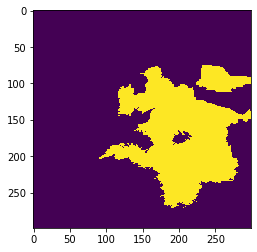

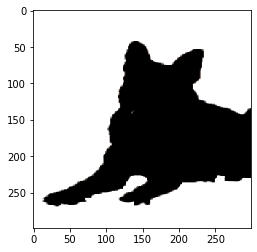

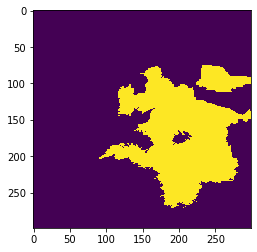

True Positive


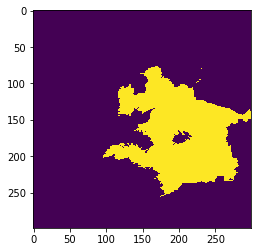

True Negative


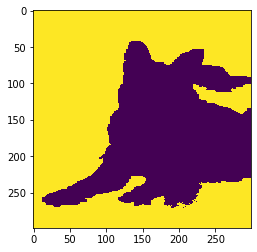

False Positive


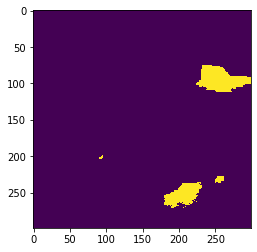

False Negative


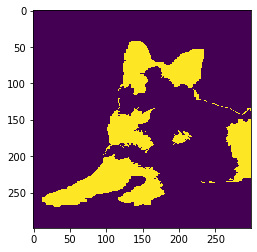

TP - FP: 19.15638527533249 3.2997393765170413
FN - TN: 16.896902719208956 60.64697262894151
Acurracy: 79.80335790427401
Precision: 85.30583781629805
Recall: 53.13353189377016
Specificity: 94.83986076370061
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 

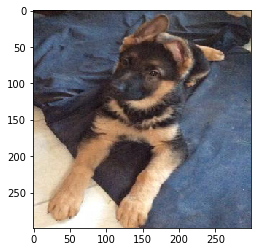

(1, 299, 299, 3)
german_shepherd, 99.94%
BACKGROUND_Google, 0.06%


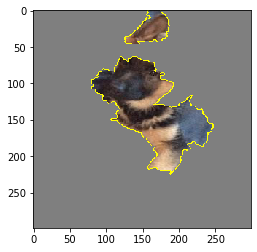

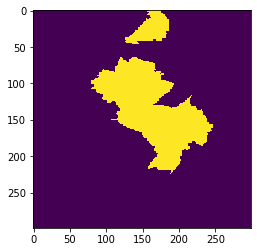

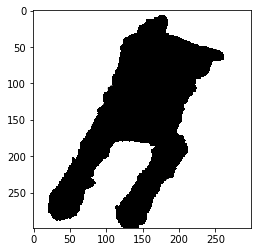

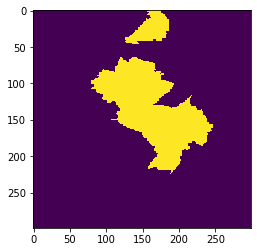

True Positive


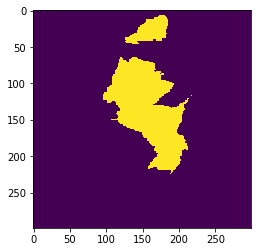

True Negative


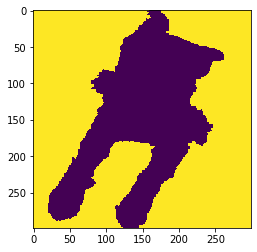

False Positive


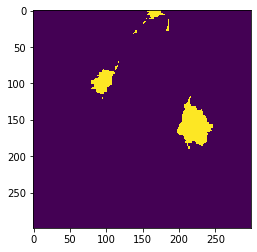

False Negative


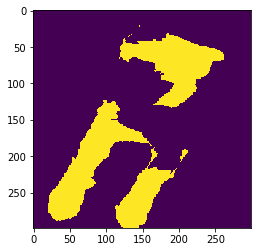

TP - FP: 12.259370700551447 3.095043679600899
FN - TN: 19.37002941801546 65.2755562018322
Acurracy: 77.53492690238365
Precision: 79.84264588038174
Recall: 38.759415779608865
Specificity: 95.47313657483149
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8

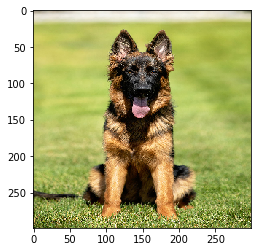

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


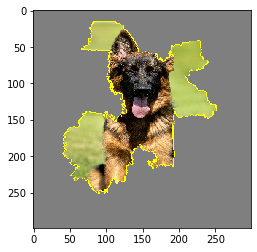

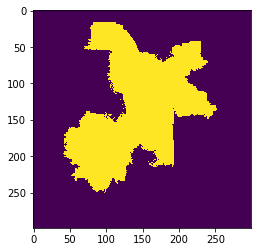

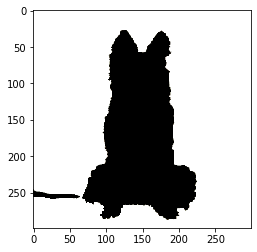

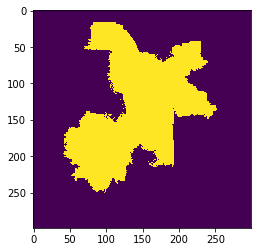

True Positive


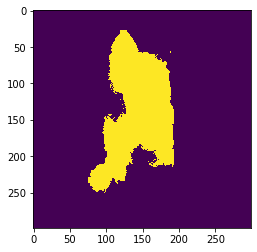

True Negative


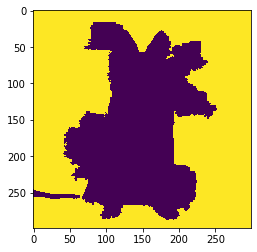

False Positive


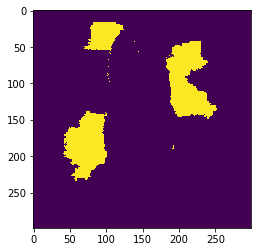

False Negative


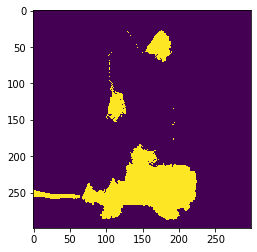

TP - FP: 15.771635664030603 10.654243241127057
FN - TN: 11.786221630630529 61.78789946421182
Acurracy: 77.55953512824242
Precision: 59.682539682539684
Recall: 57.230994033364446
Specificity: 85.29275523438947
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.

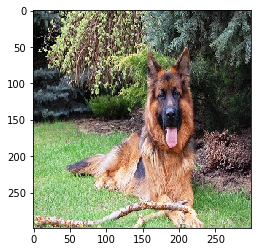

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


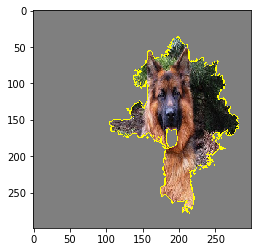

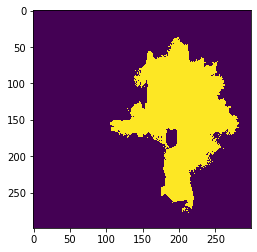

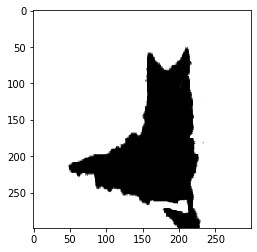

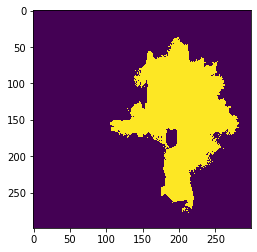

True Positive


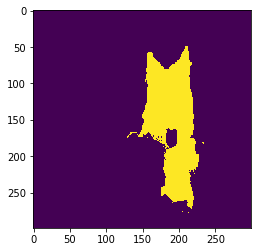

True Negative


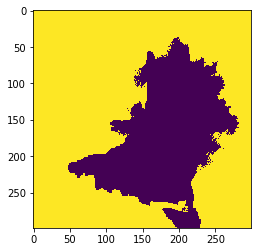

False Positive


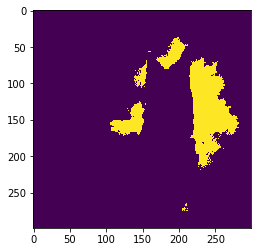

False Negative


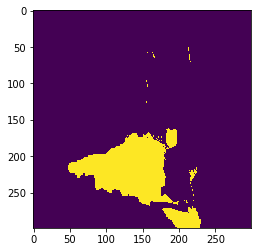

TP - FP: 11.438350801445175 8.794085077348129
FN - TN: 10.60390823368866 69.16365588751803
Acurracy: 80.6020066889632
Precision: 56.534719150818226
Recall: 51.89282452045063
Specificity: 88.71942033144414
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8

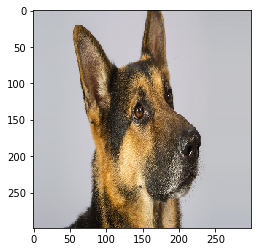

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


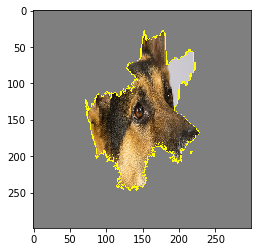

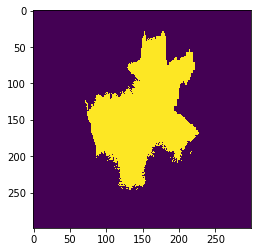

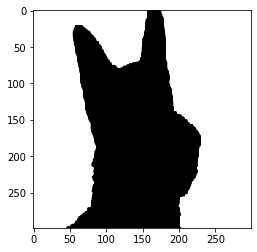

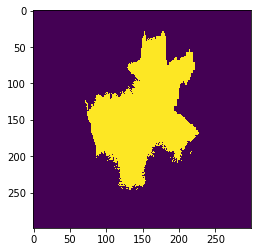

True Positive


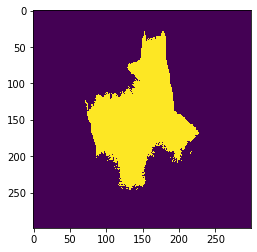

True Negative


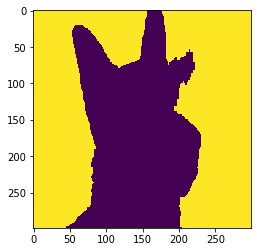

False Positive


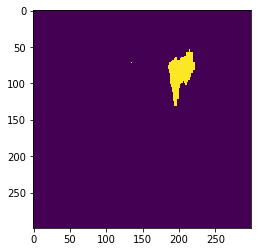

False Negative


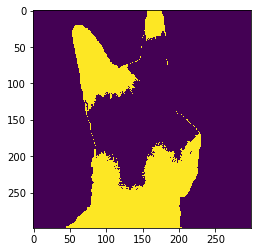

TP - FP: 17.308531224482948 1.590586235053299
FN - TN: 21.215646357423296 59.885236183040455
Acurracy: 77.19376740752341
Precision: 91.58380681818183
Recall: 44.92900902993525
Specificity: 97.41266375545851
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0,

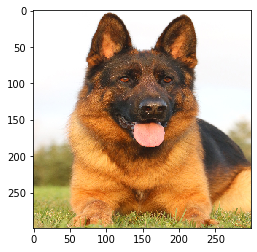

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


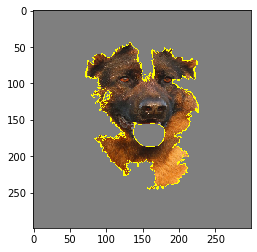

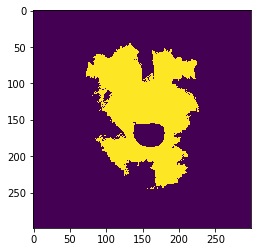

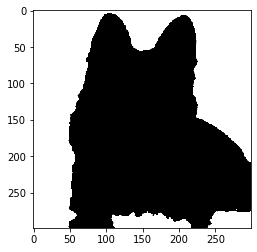

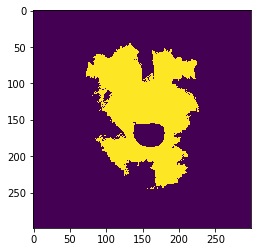

True Positive


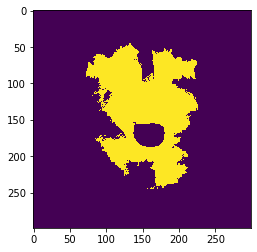

True Negative


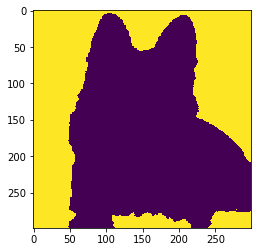

False Positive


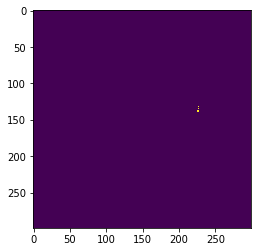

False Negative


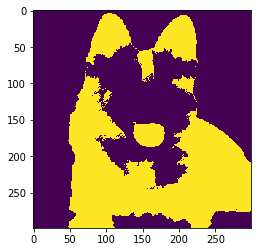

TP - FP: 18.798447444659455 0.00782989004597264
FN - TN: 38.58346103511147 42.6102616301831
Acurracy: 61.40870907484256
Precision: 99.9583655504669
Recall: 32.76023391812865
Specificity: 99.98162777879845
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8

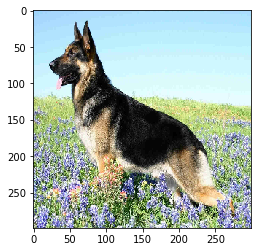

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


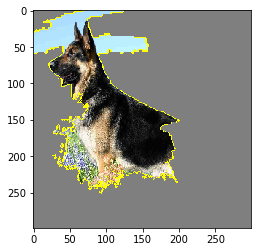

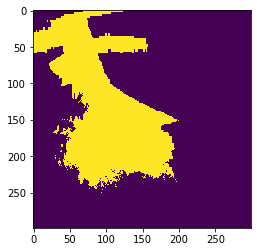

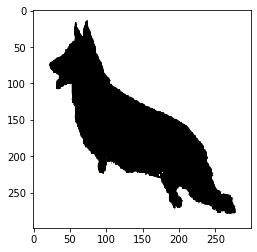

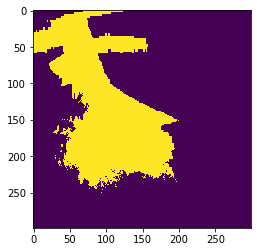

True Positive


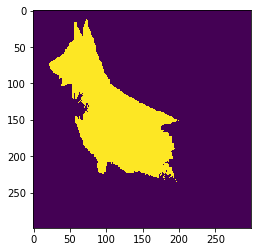

True Negative


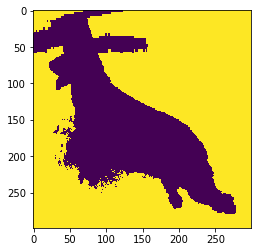

False Positive


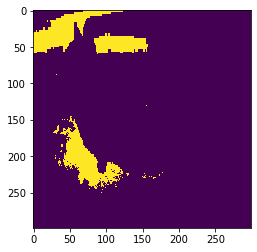

False Negative


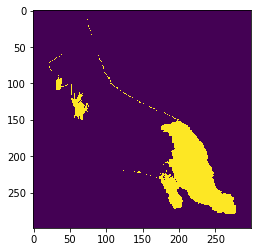

TP - FP: 18.23245824990772 8.037941410051342
FN - TN: 8.116240310511067 65.61336002952987
Acurracy: 83.8458182794376
Precision: 69.4030486247126
Recall: 69.19680760740363
Specificity: 89.08649100159465
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8.43

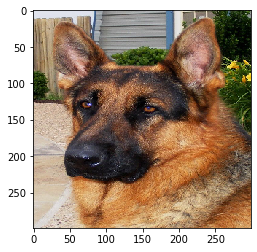

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


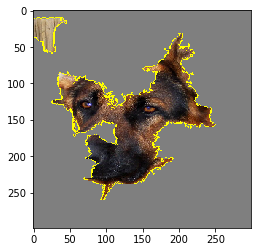

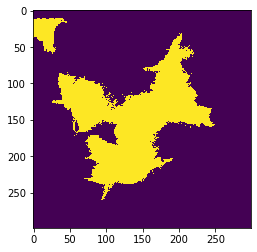

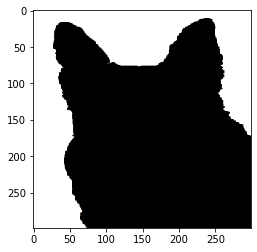

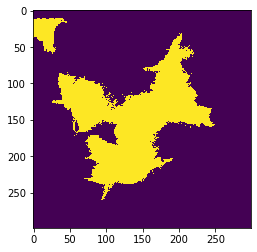

True Positive


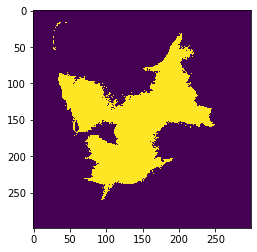

True Negative


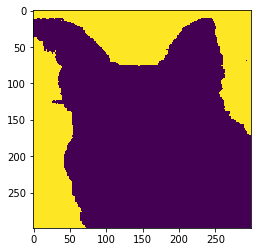

False Positive


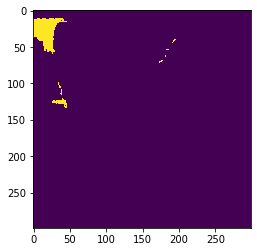

False Negative


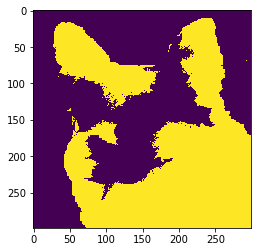

TP - FP: 20.46733258017248 1.4999832216641873
FN - TN: 46.4636860885225 31.568998109640834
Acurracy: 52.03633068981331
Precision: 93.1717500891084
Recall: 30.57974163143206
Specificity: 95.46407793262077
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8.

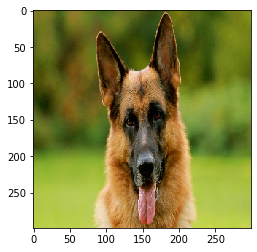

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


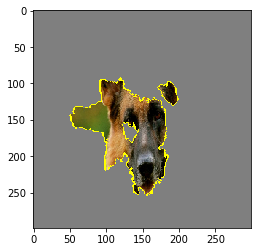

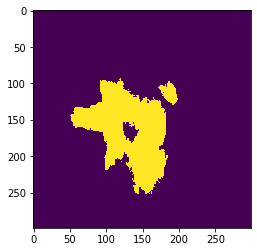

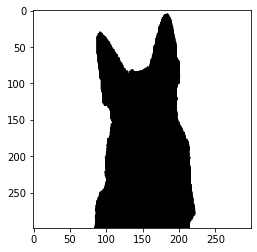

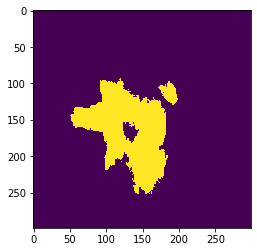

True Positive


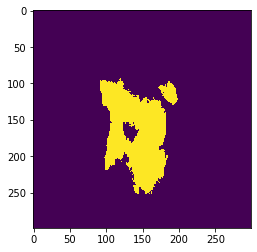

True Negative


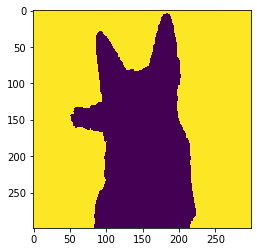

False Positive


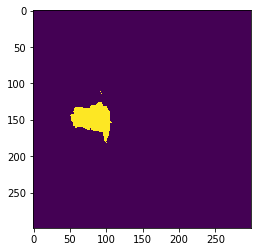

False Negative


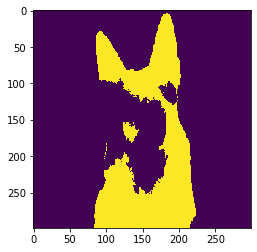

TP - FP: 10.43388776411897 1.9317457299135354
FN - TN: 21.52213062493708 66.11223588103041
Acurracy: 76.54612364514938
Precision: 84.37810945273631
Recall: 32.65077531590185
Specificity: 97.16103366649132
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8

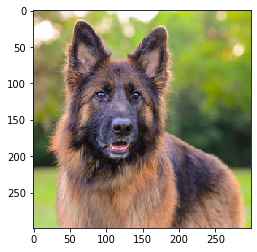

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


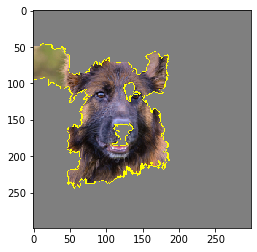

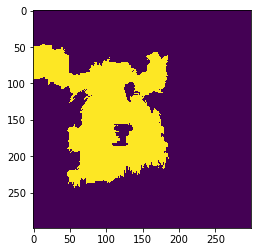

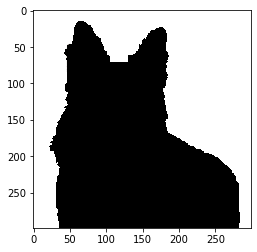

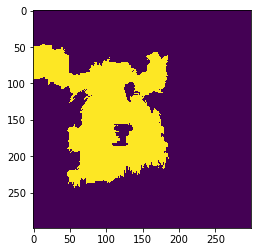

True Positive


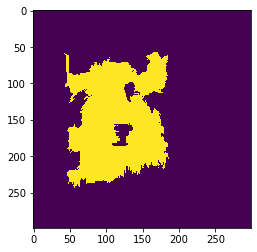

True Negative


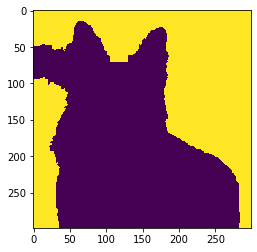

False Positive


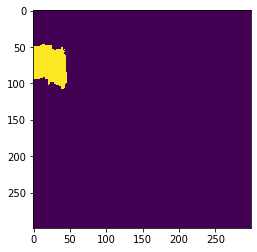

False Negative


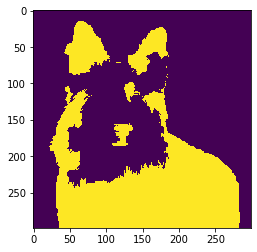

TP - FP: 19.47405510005481 2.4350958042974913
FN - TN: 33.964944463708456 44.125904631939235
Acurracy: 63.59995973199405
Precision: 88.8854852708429
Recall: 36.44165358451073
Specificity: 94.7700956133186
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8

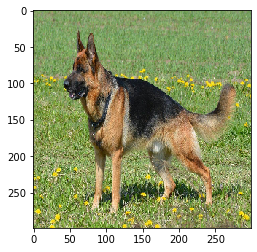

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


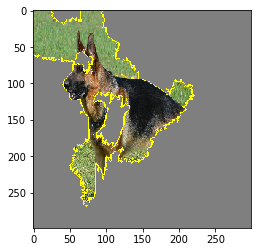

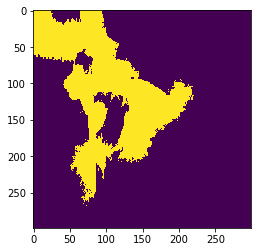

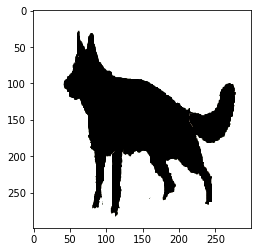

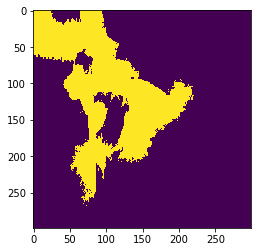

True Positive


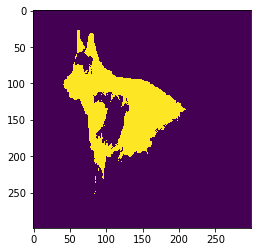

True Negative


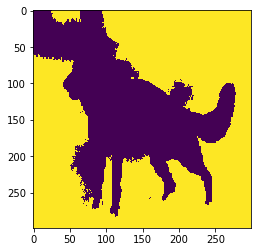

False Positive


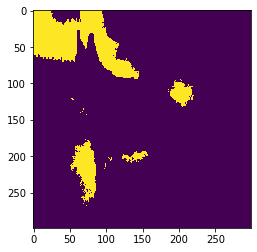

False Negative


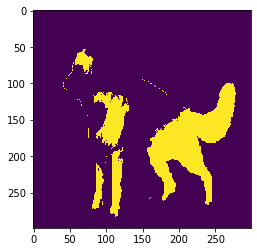

TP - FP: 12.883524792787554 10.35782597510095
FN - TN: 13.683292133197616 63.075357098913884
Acurracy: 75.95888189170144
Precision: 55.4336317258639
Recall: 48.49480021893815
Specificity: 85.8948971820259
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8

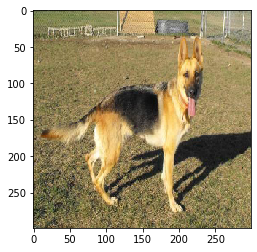

(1, 299, 299, 3)
german_shepherd, 99.99%
BACKGROUND_Google, 0.01%


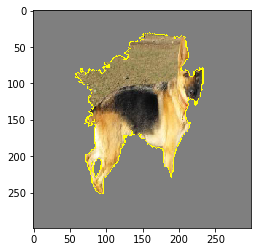

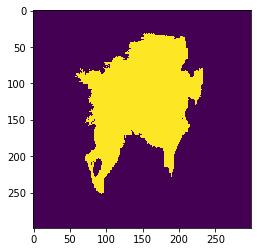

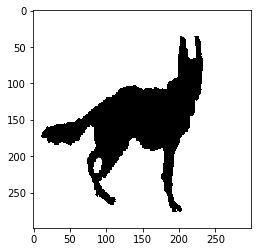

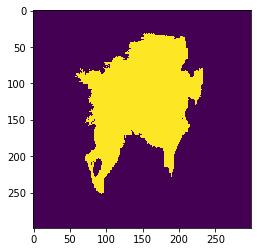

True Positive


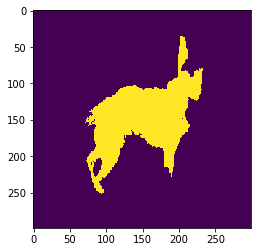

True Negative


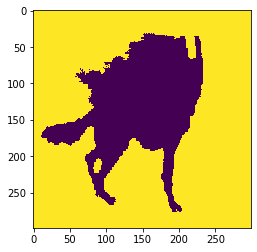

False Positive


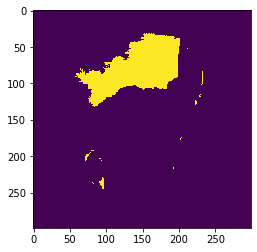

False Negative


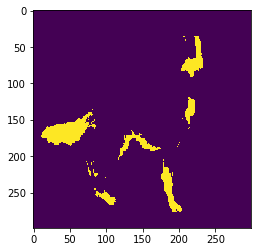

TP - FP: 14.32758022840908 8.258296887059428
FN - TN: 4.788537040972695 72.6255858435588
Acurracy: 86.95316607196787
Precision: 63.43601426307449
Recall: 74.9502633118783
Specificity: 89.7899351412648
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8.431

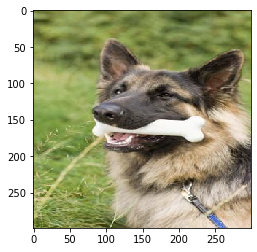

(1, 299, 299, 3)
german_shepherd, 99.89%
BACKGROUND_Google, 0.11%


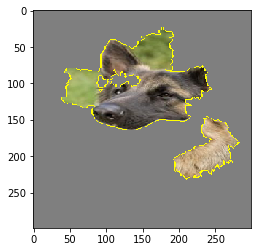

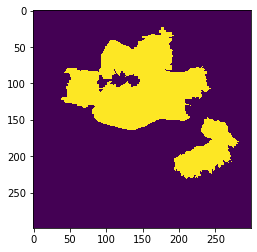

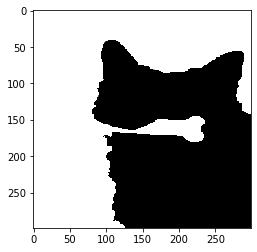

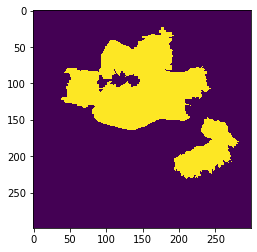

True Positive


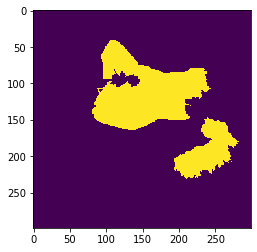

True Negative


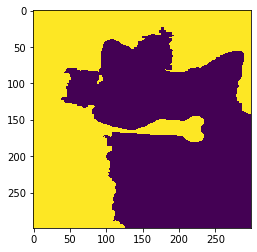

False Positive


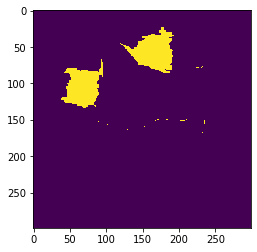

False Negative


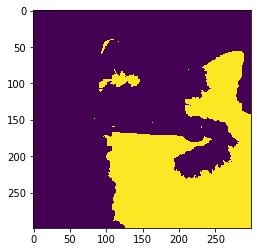

TP - FP: 16.271630071251998 5.106206865695015
FN - TN: 31.074596481023704 47.54756658202928
Acurracy: 63.81919665328128
Precision: 76.11448304730011
Recall: 34.36732186732186
Specificity: 90.3022964331995
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8

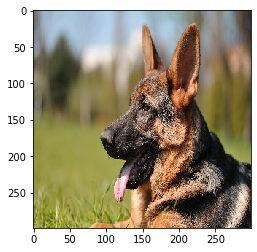

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


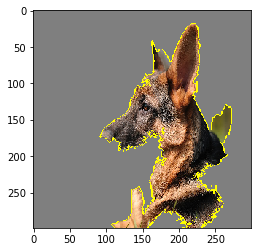

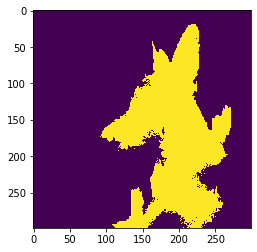

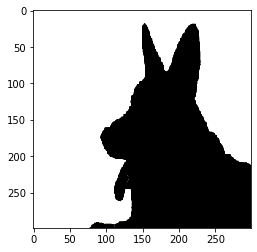

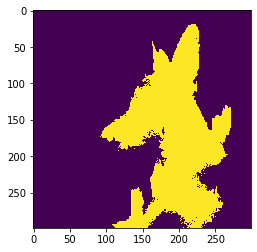

True Positive


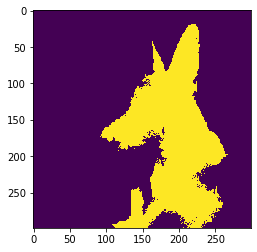

True Negative


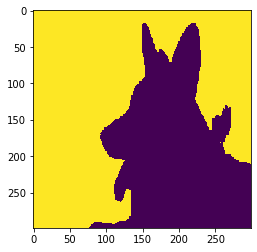

False Positive


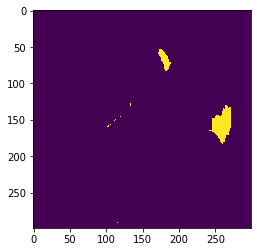

False Negative


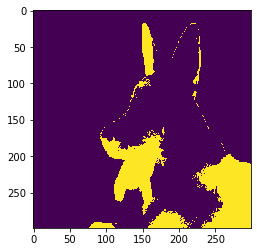

TP - FP: 24.85542667307972 1.3008803033523115
FN - TN: 13.625127235713247 60.218565787854715
Acurracy: 85.07399246093443
Precision: 95.02651385562778
Recall: 64.59217487355386
Specificity: 97.88541609847451
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0,

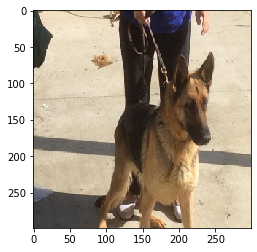

(1, 299, 299, 3)
german_shepherd, 99.99%
BACKGROUND_Google, 0.01%


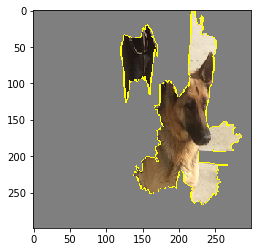

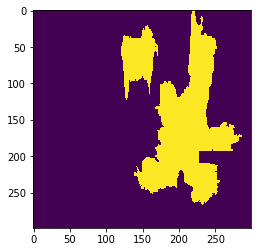

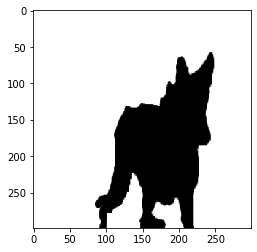

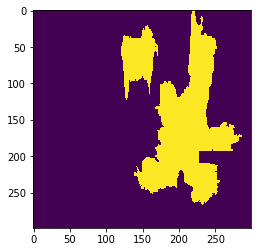

True Positive


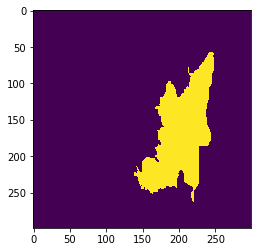

True Negative


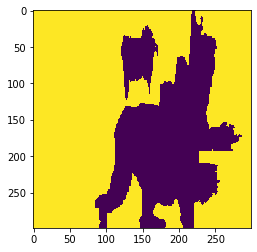

False Positive


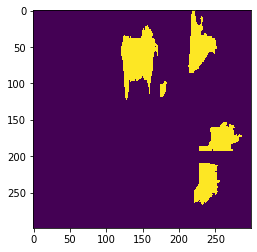

False Negative


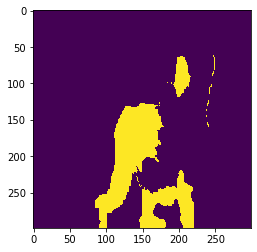

TP - FP: 11.683314504312033 8.305276227335264
FN - TN: 12.171004798604041 67.84040446974866
Acurracy: 79.5237189740607
Precision: 58.44991606043648
Recall: 48.97777360967833
Specificity: 89.092912229159
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8.4

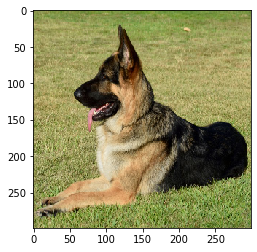

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


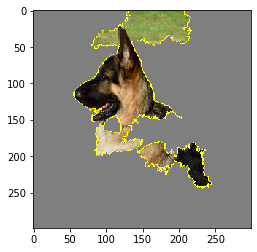

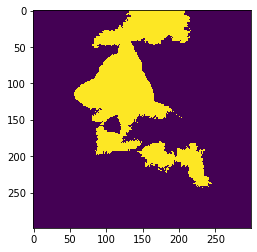

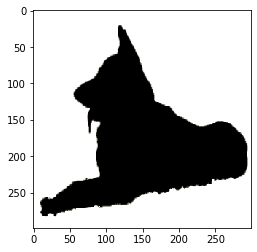

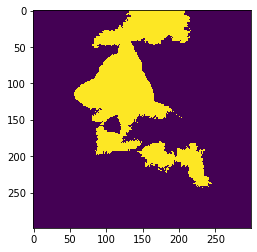

True Positive


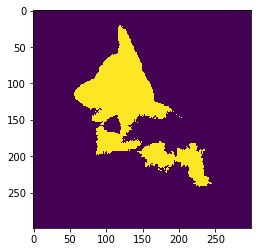

True Negative


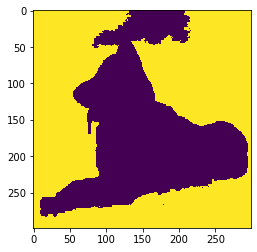

False Positive


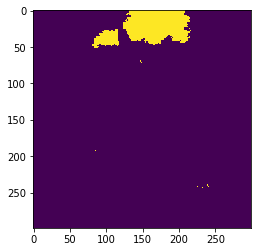

False Negative


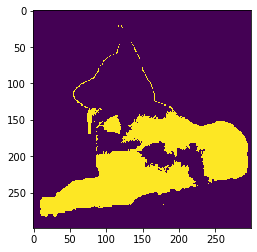

TP - FP: 13.79514770528294 4.609568125636178
FN - TN: 21.30624937081241 60.28903479826847
Acurracy: 74.0841825035514
Precision: 74.95441837850979
Recall: 39.300850833306775
Specificity: 92.89727680110306
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8.

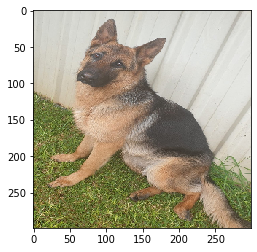

(1, 299, 299, 3)
german_shepherd, 99.99%
BACKGROUND_Google, 0.01%


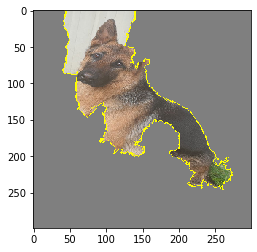

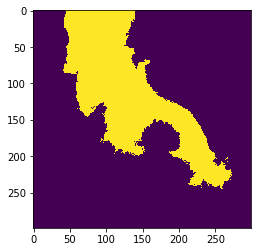

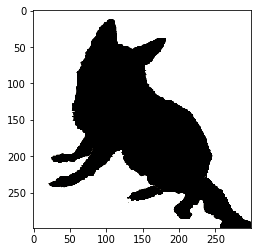

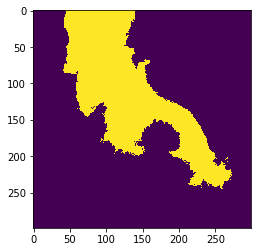

True Positive


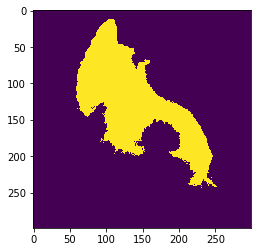

True Negative


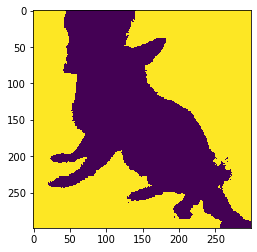

False Positive


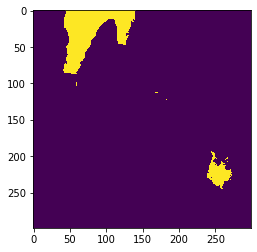

False Negative


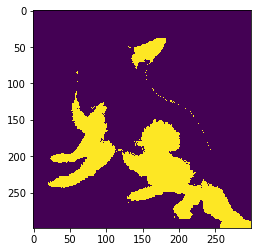

TP - FP: 18.42037561101106 5.6352837216585945
FN - TN: 17.007639735573427 58.93670093175692
Acurracy: 77.35707654276797
Precision: 76.5739793545987
Recall: 51.993811763962995
Specificity: 91.27286585365853
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 

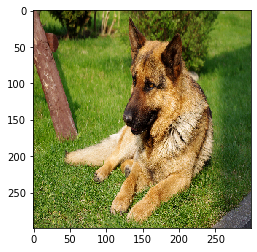

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


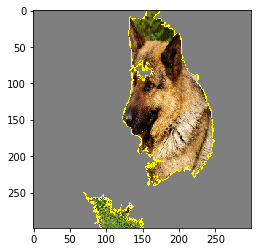

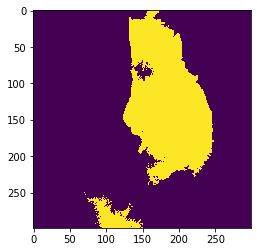

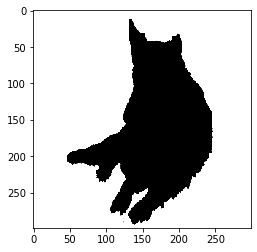

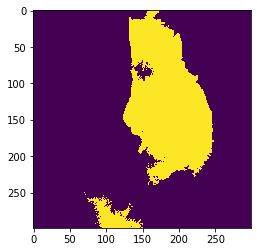

True Positive


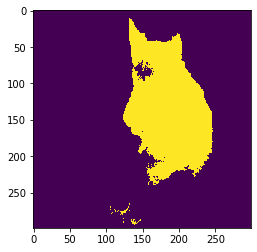

True Negative


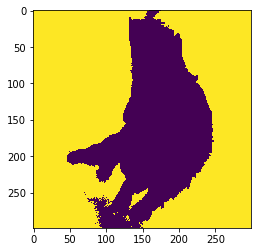

False Positive


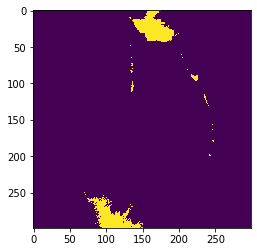

False Negative


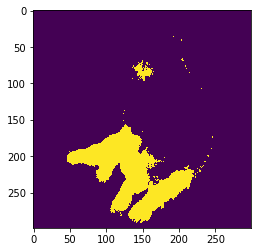

TP - FP: 18.85996800930638 3.31316204516728
FN - TN: 10.483104215836512 67.34376572968982
Acurracy: 86.2037337389962
Precision: 85.05776118650054
Recall: 64.2740060229482
Specificity: 95.31091691995948
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8.43

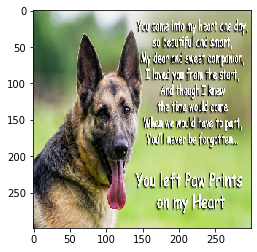

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


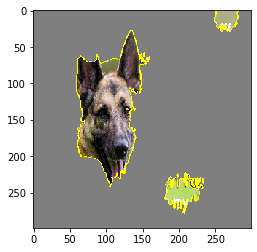

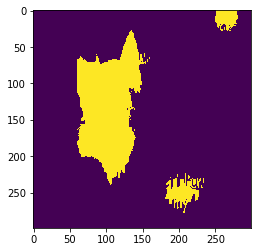

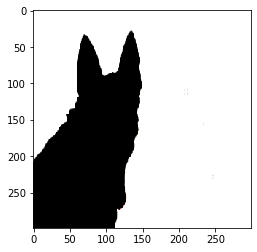

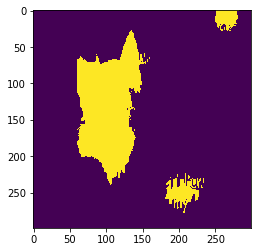

True Positive


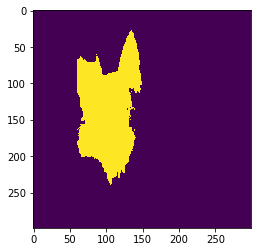

True Negative


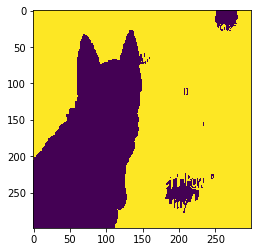

False Positive


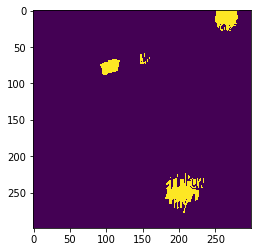

False Negative


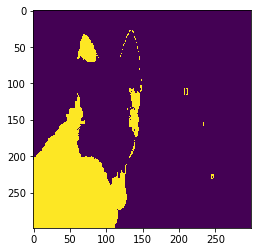

TP - FP: 12.554669410856704 2.7460542946946904
FN - TN: 17.007639735573427 67.69163655887517
Acurracy: 80.24630596973188
Precision: 82.0527816360845
Recall: 42.46850051080253
Specificity: 96.10144191069047
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 

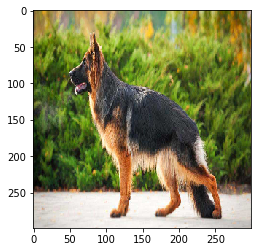

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


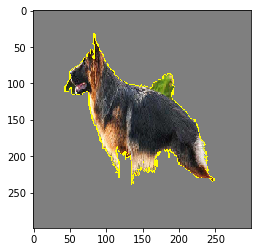

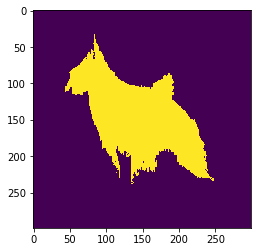

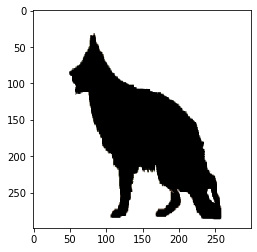

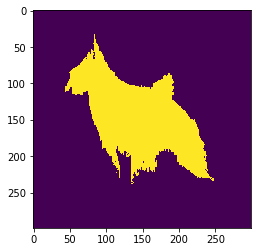

True Positive


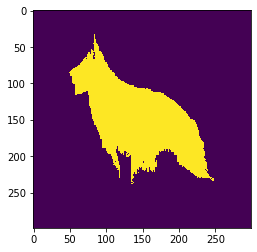

True Negative


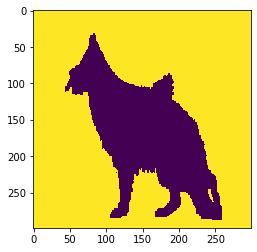

False Positive


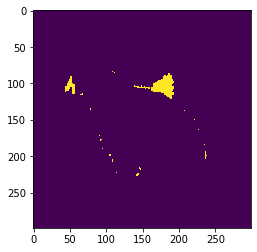

False Negative


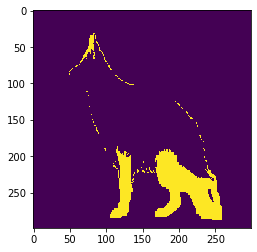

TP - FP: 18.056845001733763 1.050323821881187
FN - TN: 7.718034473887317 73.17479670249773
Acurracy: 91.23164170423149
Precision: 94.50298559887601
Recall: 70.05598229397214
Specificity: 98.58494831067843
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8

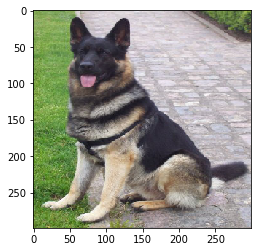

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


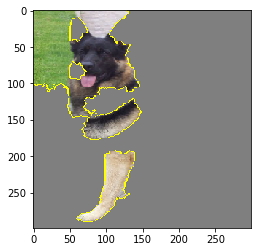

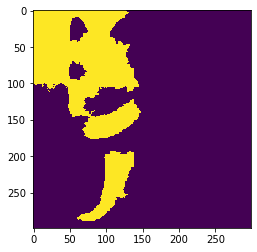

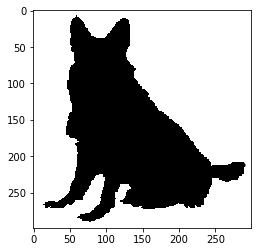

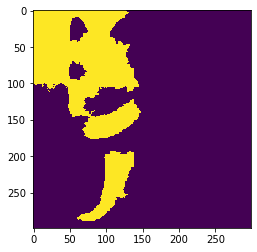

True Positive


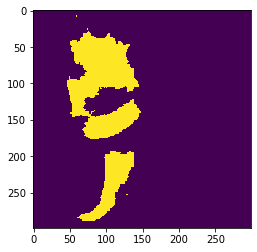

True Negative


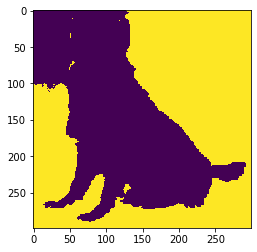

False Positive


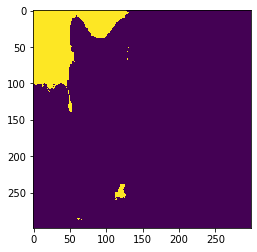

False Negative


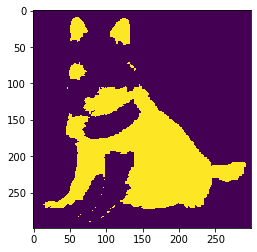

TP - FP: 12.673236317267145 8.288497891522466
FN - TN: 24.87891634321764 54.15934944799275
Acurracy: 66.83258576525989
Precision: 60.458911419423686
Recall: 33.7483617300131
Specificity: 86.72732809113542
[['11.german-shepherd-ap-aozjlq-645.png', 'german_shepherd', 99.99979734420776, 13.677699354593347, 3.927249135915706, 14.855538528651804, 67.53951298083915, 82.39505150949095, 52.06397741973422, 79.09123392091472, 83.15911250671405, 62.79284177679015], ['11.german-shepherd-dog.png', 'german_shepherd', 99.99985694885254, 4.979810069238599, 16.74925336405633, 20.47068824733504, 57.80024831937003, 78.27093656670507, 80.43334944842438, 54.9992486851991, 92.06784734347718, 65.32805026058399], ['11.gsd_bred_to_do_header_.png', 'german_shepherd', 99.9998688697815, 13.013277256406527, 10.421583651189584, 10.678851466985828, 65.88628762541806, 76.5651390924039, 45.073414852934235, 50.6096268023749, 83.50652848859464, 47.68135847171932], ['14.NGHT-Boxed640x480.png', 'german_shepherd', 100.0, 8

In [10]:
#glob.glob("*.png*")

def path_leaf(path):
    head, tail = ntpath.split(path)
    return tail or ntpath.basename(head)


count=0
for f in glob.glob("C:/Users/andradee/Documents/audiodeep/image_downloader/image_downloader/images/german-shepherd 2020_09_11_total/teste/*.png"):
    filen=path_leaf(f)
    count=count+1
    print(count, filen )
    getmasks(filen)
    data

df = pd.DataFrame(data, columns=['Filename', 'class_lime', 'prob', 'fp', 'fn','tp','tn', 'acc', 'pre', 'rec', 'spe','f1'])



In [11]:
df

,Filename,class_lime,prob,fp,fn,tp,tn,acc,pre,rec,spe,f1
0,11.german-shepherd-ap-aozjlq-645.png,german_shepherd,99.999797,13.677699,3.927249,14.855539,67.539513,82.395052,52.063977,79.091234,83.159113,62.792842
1,11.german-shepherd-dog.png,german_shepherd,99.999857,4.979810,16.749253,20.470688,57.800248,78.270937,80.433349,54.999249,92.067847,65.328050
2,11.gsd_bred_to_do_header_.png,german_shepherd,99.999869,13.013277,10.421584,10.678851,65.886288,76.565139,45.073415,50.609627,83.506528,47.681358
3,14.NGHT-Boxed640x480.png,german_shepherd,100.000000,8.431673,19.857720,12.092706,59.617901,71.710607,58.918742,37.848341,87.609514,46.089570
4,15.Image5.png,german_shepherd,99.998033,3.299739,16.896903,19.156385,60.646973,79.803358,85.305838,53.133532,94.839861,65.481380
5,23.p9145777.png,german_shepherd,99.939716,3.095044,19.370029,12.259371,65.275556,77.534927,79.842646,38.759416,95.473137,52.185506
6,25.flora_1.png,german_shepherd,99.999988,10.654243,11.786222,15.771636,61.787899,77.559535,59.682540,57.230994,85.292755,58.431064
7,27.long-hair-gsd.png,german_shepherd,99.999928,8.794085,10.603908,11.438351,69.163656,80.602007,56.534719,51.892825,88.719420,54.114410
8,31.GSD_hero.png,german_shepherd,99.999094,1.590586,21.215646,17.308531,59.885236,77.193767,91.583807,44.929009,97.412664,60.284006
9,33.6a2243882af74b532f9b17ec2fa059ad.png,german_shepherd,100.000000,0.007830,38.583461,18.798447,42.610262,61.408709,99.958366,32.760234,99.981628,49.347408


In [12]:
writer = pd.ExcelWriter('output_base1.xlsx', engine='xlsxwriter')
df.to_excel(writer,'output')
writer.save()